day-01-market-data-return-analysis/
data/
notebooks/
src/
outputs/charts/
outputs/tables/

1. Objective
2. Data Collection
3. Data Cleaning
4. Return Analysis
5. Risk Metrics
6. Visualizations
7. Conclusion

In [1]:
#Get an API key
API_KEY = "your_key_here"

In [2]:
#Import Libraries
import requests
import pandas as pd

API_KEY = "your_key_here"
symbol = "EURUSD"

url = (
    "https://www.alphavantage.co/query"
    f"?function=FX_DAILY&from_symbol=EUR&to_symbol=USD"
    f"&outputsize=full&apikey={API_KEY}"
)

response = requests.get(url)
data = response.json()

In [3]:
#Convert JSON to a clean DataFrame
ts = data["Time Series FX (Daily)"]
df = pd.DataFrame(ts).T
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.columns = ["open", "high", "low", "close"]
df = df.astype(float)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000 entries, 2007-01-16 to 2026-03-17
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5000 non-null   float64
 1   high    5000 non-null   float64
 2   low     5000 non-null   float64
 3   close   5000 non-null   float64
dtypes: float64(4)
memory usage: 195.3 KB


In [4]:
#Save a copy
df.to_csv("data/eurusd_daily_raw.csv")

In [5]:
#Create the core return fields; Now compute the minimum viable analytics layer
import numpy as np

df["simple_return"] = df["close"].pct_change()
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["cum_return"] = (1 + df["simple_return"]).cumprod() - 1

In [6]:
#Generate descriptive statistics
summary = df["simple_return"].describe()
skew = df["simple_return"].skew()
kurt = df["simple_return"].kurt()

print(summary)
print("Skewness:", skew)
print("Kurtosis:", kurt)

count    4999.000000
mean       -0.000007
std         0.005570
min        -0.026756
25%        -0.003076
50%         0.000042
75%         0.003042
max         0.038119
Name: simple_return, dtype: float64
Skewness: 0.11597807687072732
Kurtosis: 2.6408677482439025


In [7]:
#Measure annualized return and volatility
trading_days = 252

annualized_return = df["simple_return"].mean() * trading_days
annualized_vol = df["simple_return"].std() * (trading_days ** 0.5)

print("Annualized return:", annualized_return)
print("Annualized volatility:", annualized_vol)

Annualized return: -0.0017879931605992792
Annualized volatility: 0.08842156023652105


In [8]:
#Compute drawdown
df["equity_curve"] = (1 + df["simple_return"]).cumprod()
df["rolling_peak"] = df["equity_curve"].cummax()
df["drawdown"] = df["equity_curve"] / df["rolling_peak"] - 1

max_drawdown = df["drawdown"].min()
print("Max Drawdown:", max_drawdown)

Max Drawdown: -0.40022505626407234


In [9]:
#Creating a saving folder
import os
os.makedirs("outputs/tables/day01_metrics.csv",exist_ok=True)
os.makedirs("outputs/charts", exist_ok=True)

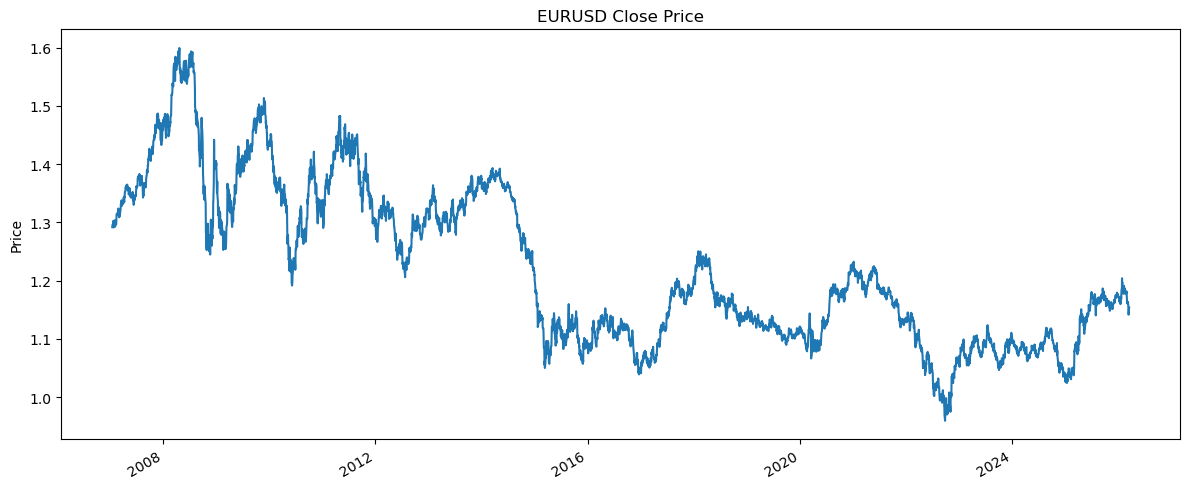

In [10]:
#VISUALIZATION: Create the required charts
#Chart 1: Closing price over time
import matplotlib.pyplot as plt

df["close"].plot(figsize=(12, 5), title="EURUSD Close Price")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("outputs/charts/price_series.png")
plt.show()

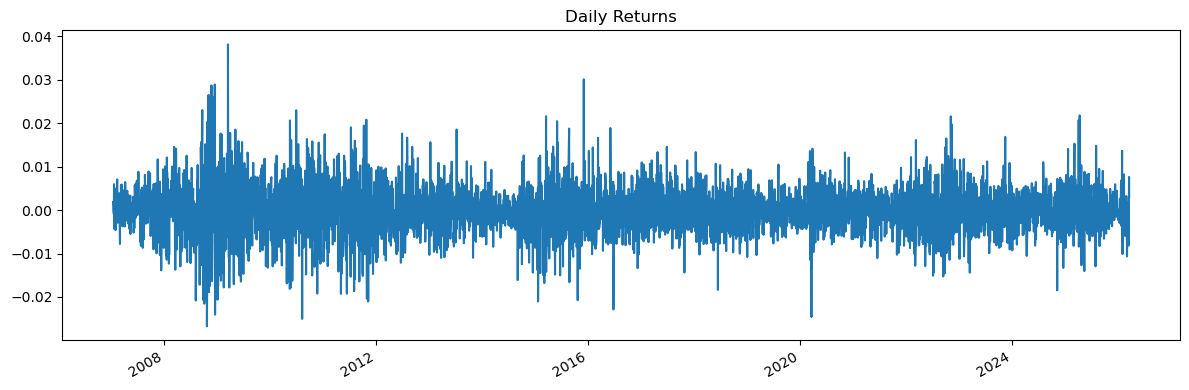

In [11]:
#Chart 2:Daily returns
df["simple_return"].plot(figsize=(12, 4), title="Daily Returns")
plt.tight_layout()
plt.savefig("outputs/charts/daily_returns.png")
plt.show()



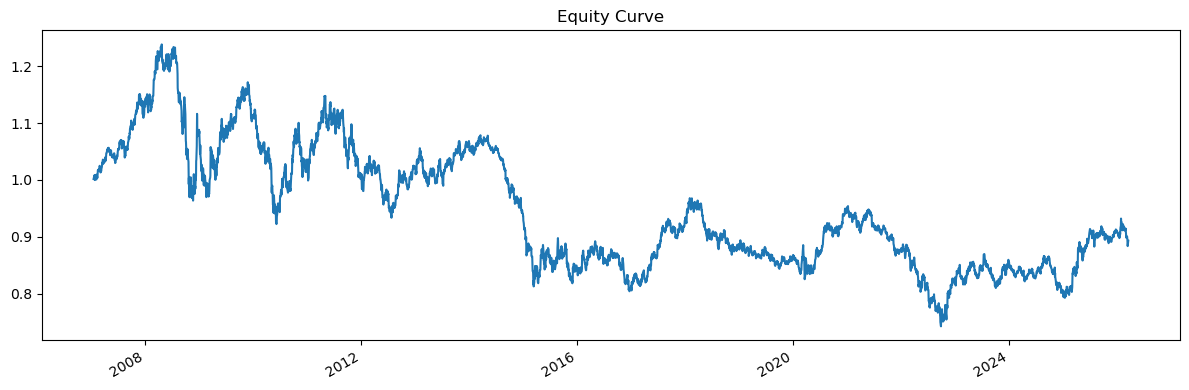

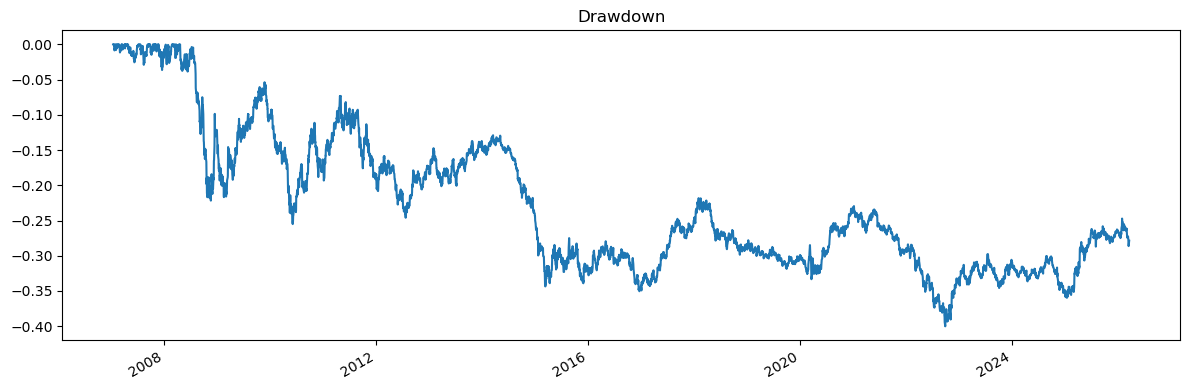

In [12]:
#Chart 4:Equity curve and drawdown
df["equity_curve"].plot(figsize=(12, 4), title="Equity Curve")
plt.tight_layout()
plt.savefig("outputs/charts/equity_curve.png")
plt.show()

df["drawdown"].plot(figsize=(12, 4), title="Drawdown")
plt.tight_layout()
plt.savefig("outputs/charts/drawdown.png")
plt.show()

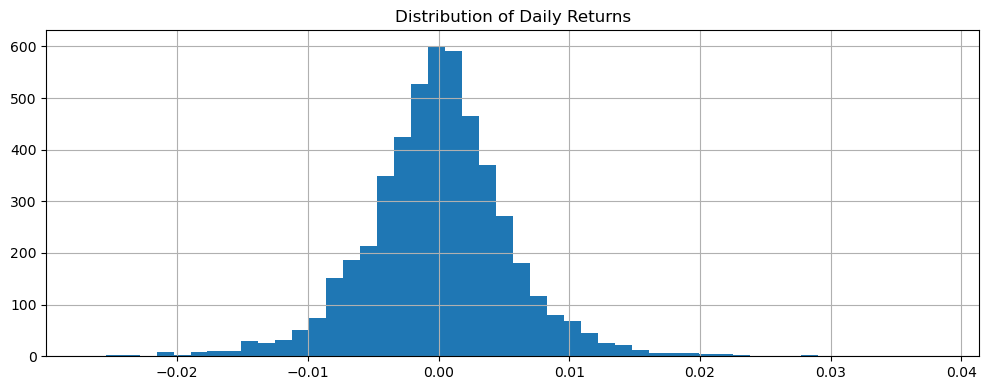

In [13]:
#Chart 3: Return distribution
df["simple_return"].hist(bins=50, figsize=(10, 4))
plt.title("Distribution of Daily Returns")
plt.tight_layout()
plt.savefig("outputs/charts/return_distribution.png")
plt.show()



📊 Analyst Interpretation

The asset exhibits clear periods of volatility clustering, where high-volatility phases are followed by continued instability, a common characteristic of financial time series. Daily returns are largely centered around zero, indicating the absence of consistent directional drift, but are punctuated by occasional extreme movements, reflecting tail risk.

The return distribution deviates from normality, suggesting the presence of fat tails and potential skewness, which has important implications for risk modeling and strategy design. Additionally, the observed maximum drawdown underscores the significant downside risk associated with a passive holding approach.

Overall, these findings highlight that any trading or investment strategy applied to this asset must be evaluated not only on expected returns but also on risk-adjusted performance and drawdown control.

In [15]:
#Create a small results table.
metrics = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Max Drawdown",
        "Mean Daily Return",
        "Daily Return Std",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        annualized_return,
        annualized_vol,
        max_drawdown,
        df["simple_return"].mean(),
        df["simple_return"].std(),
        skew,
        kurt
    ]
})

metrics.to_csv("outputs/tables/day01_metrics_v2.csv", index=False)
metrics

,Metric,Value
0,Annualized Return,-0.001788
1,Annualized Volatility,0.088422
2,Max Drawdown,-0.400225
3,Mean Daily Return,-0.000007
4,Daily Return Std,0.005570
5,Skewness,0.115978
6,Kurtosis,2.640868
